# Single-Variable Regressions: What Predicts HDB Resale Prices?

**Data:** 50,718 HDB resale transactions from **May 2024 to April 2026** (most recent 2 years). See Notebook 1 for why we use a 2-year window.

We run `lm(resale_price ~ X)` for each predictor individually to understand which variables, on their own, explain the most variation in HDB resale prices.

**Dependent variable:** `resale_price` (raw resale price in dollars)

**Robust standard errors:** We use HC1 (heteroskedasticity-consistent) standard errors via `sandwich`/`lmtest` since price variance is larger for expensive flats. R-squared and coefficients are unchanged; only the standard errors and p-values are adjusted.

**Predictors tested:**
1. `town` — location
2. `flat_type` — 2-room, 3-room, 4-room, 5-room, executive
3. `floor_area_sqm` — size of the flat
4. `storey_mid` — midpoint of the storey range
5. `remaining_lease_years` — years left on the 99-year lease
6. `flat_model_grouped` — grouped flat model categories
7. `ends_in_8` — whether the price ends in 8 (lucky number hypothesis)
8-37. Geographic proximity, feng shui proximity, price numerology, floor/block superstition, cultural timing

In [1]:
# Python setup
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(broom)
library(scales)
library(sandwich)
library(lmtest)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor

Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



In [3]:
%%R
df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
cat(sprintf("Loaded %s rows and %s columns\n", comma(nrow(df)), ncol(df)))
glimpse(df)

Loaded 50,718 rows and 63 columns


Rows: 50,718

Columns: 63

$ month                    <date> 2024-05-01, 2024-05-01, 2024-05-01, 2024-05-…
$ town                     <chr> "ANG MO KIO", "ANG MO KIO", "ANG MO KIO", "AN…
$ block                    <chr> "405", "463", "542", "446", "540", "403", "46…
$ street_name              <chr> "ANG MO KIO AVE 10", "ANG MO KIO AVE 10", "AN…
$ resale_price             <dbl> 350000, 350000, 352000, 355000, 355000, 35600…
$ log_resale_price         <dbl> 5.544068, 5.544068, 5.546543, 5.550228, 5.550…
$ flat_type                <chr> "3 ROOM", "3 ROOM", "3 ROOM", "3 ROOM", "3 RO…
$ flat_model               <chr> "New Generation", "New Generation", "New Gene…
$ floor_area_sqm           <dbl> 67, 68, 68, 68, 68, 67, 67, 68, 68, 68, 60, 6…
$ storey_range             <chr> "10 TO 12", "01 TO 03", "01 TO 03", "04 TO 06…
$ storey_mid               <dbl> 11, 2, 2, 5, 5, 5, 2, 2, 8, 5, 8, 2, 8, 2, 5,…
$ lease_commence_date      <dbl> 1979, 1980, 1981, 1979, 1981, 1979, 1984, 198…
$ remaining_lease_years    <dbl> 54, 55,

---
## 1. Town

Does location alone predict resale price?

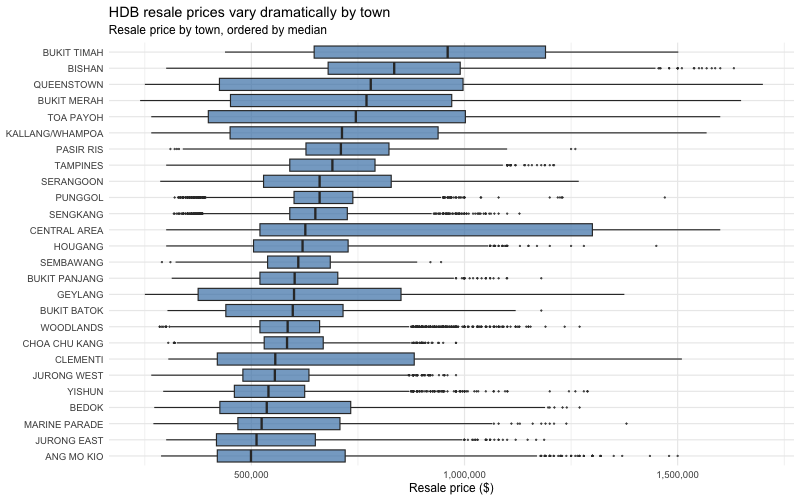

In [4]:
%%R -w 800 -h 500
ggplot(df, aes(x = reorder(town, resale_price, FUN = median), y = resale_price)) +
  geom_boxplot(fill = "steelblue", alpha = 0.7, outlier.size = 0.3) +
  scale_y_continuous(labels = comma) +
  coord_flip() +
  labs(
    title = "HDB resale prices vary dramatically by town",
    subtitle = "Resale price by town, ordered by median",
    x = NULL,
    y = "Resale price ($)"
  ) +
  theme_minimal(base_size = 12)

In [5]:
%%R
model_town <- lm(resale_price ~ town, data = df)
coeftest(model_town, vcov = vcovHC(model_town, type = "HC1"))
cat(sprintf("\nR-squared: %.4f\n", summary(model_town)$r.squared))


R-squared: 0.1119


---
## 2. Flat type

How much does flat type (2-room, 3-room, etc.) explain on its own?

In [6]:
%%R
model_flat_type <- lm(resale_price ~ flat_type, data = df)
coeftest(model_flat_type, vcov = vcovHC(model_flat_type, type = "HC1"))
cat(sprintf("\nR-squared: %.4f\n", summary(model_flat_type)$r.squared))


R-squared: 0.4593


---
## 3. Floor area (sqm)

Bigger flats cost more — but how strong is the relationship?

`geom_smooth()` using formula = 'y ~ x'


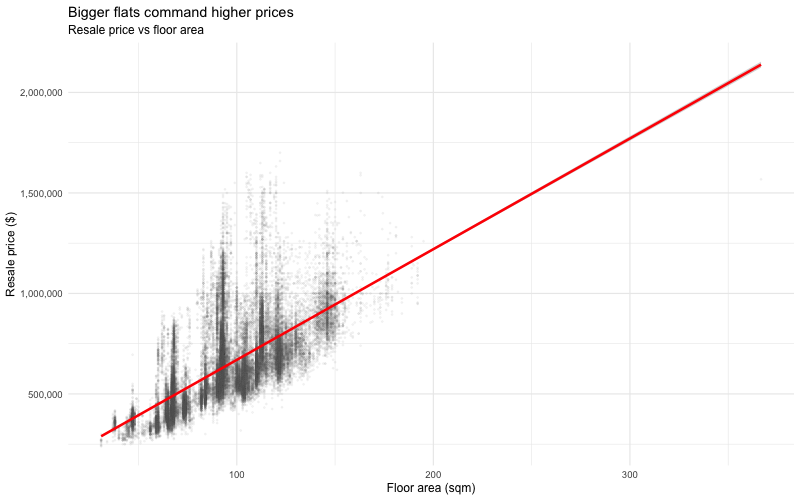

In [7]:
%%R -w 800 -h 500
ggplot(df, aes(x = floor_area_sqm, y = resale_price)) +
  geom_point(alpha = 0.05, size = 0.5, colour = "grey40") +
  geom_smooth(method = "lm", colour = "red", linewidth = 1.2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Bigger flats command higher prices",
    subtitle = "Resale price vs floor area",
    x = "Floor area (sqm)",
    y = "Resale price ($)"
  ) +
  theme_minimal(base_size = 12)

In [8]:
%%R
model_area <- lm(resale_price ~ floor_area_sqm, data = df)
coeftest(model_area, vcov = vcovHC(model_area, type = "HC1"))
cat(sprintf("\nR-squared: %.4f\n", summary(model_area)$r.squared))
cat(sprintf("\nInterpretation: Each additional sqm adds $%s to resale price\n", comma(round(coef(model_area)["floor_area_sqm"]))))


R-squared: 0.4300



Interpretation: Each additional sqm adds $5,507 to resale price


---
## 4. Storey (midpoint)

Higher floors = higher prices. Each additional floor adds approximately how much to price?

`geom_smooth()` using formula = 'y ~ x'


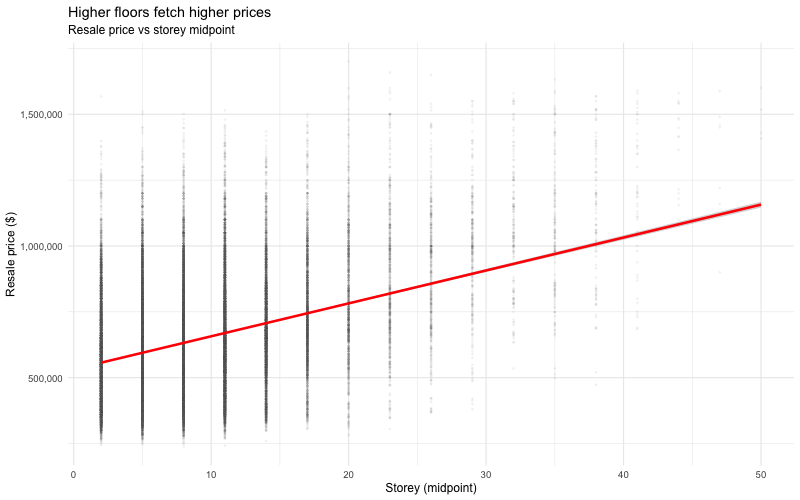

In [9]:
%%R -w 800 -h 500
ggplot(df, aes(x = storey_mid, y = resale_price)) +
  geom_point(alpha = 0.05, size = 0.5, colour = "grey40") +
  geom_smooth(method = "lm", colour = "red", linewidth = 1.2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Higher floors fetch higher prices",
    subtitle = "Resale price vs storey midpoint",
    x = "Storey (midpoint)",
    y = "Resale price ($)"
  ) +
  theme_minimal(base_size = 12)

In [10]:
%%R
model_storey <- lm(resale_price ~ storey_mid, data = df)
coeftest(model_storey, vcov = vcovHC(model_storey, type = "HC1"))

storey_coef <- coef(model_storey)["storey_mid"]
cat(sprintf("\nR-squared: %.4f\n", summary(model_storey)$r.squared))
cat(sprintf("\nInterpretation: Each additional floor adds approximately $%s to price\n", comma(round(storey_coef))))


R-squared: 0.1382



Interpretation: Each additional floor adds approximately $12,502 to price


---
## 5. Remaining lease years

Lease decay is a known factor. We use a LOESS smooth to check for non-linearity.

`geom_smooth()` using formula = 'y ~ x'


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: Failed to fit group -1.
Caused by error in `predLoess()`:
! workspace required (3858967834) is too large probably because of setting 'se = TRUE'. 
  


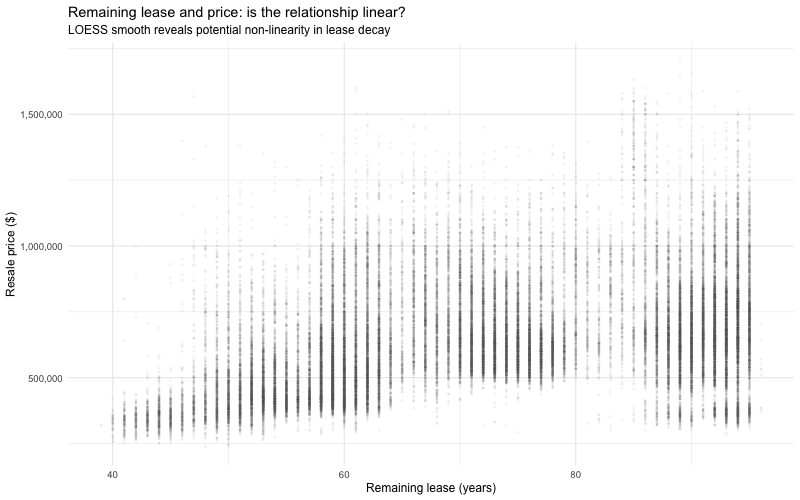

In [11]:
%%R -w 800 -h 500
ggplot(df, aes(x = remaining_lease_years, y = resale_price)) +
  geom_point(alpha = 0.05, size = 0.5, colour = "grey40") +
  geom_smooth(method = "loess", colour = "blue", linewidth = 1.2) +
  scale_y_continuous(labels = comma) +
  labs(
    title = "Remaining lease and price: is the relationship linear?",
    subtitle = "LOESS smooth reveals potential non-linearity in lease decay",
    x = "Remaining lease (years)",
    y = "Resale price ($)"
  ) +
  theme_minimal(base_size = 12)

In [12]:
%%R
model_lease <- lm(resale_price ~ remaining_lease_years, data = df)
coeftest(model_lease, vcov = vcovHC(model_lease, type = "HC1"))
cat(sprintf("\nR-squared: %.4f\n", summary(model_lease)$r.squared))
cat(sprintf("\nInterpretation: Each additional year of remaining lease adds $%s to price\n", comma(round(coef(model_lease)["remaining_lease_years"]))))


R-squared: 0.1474



Interpretation: Each additional year of remaining lease adds $5,054 to price


---
## 6. Flat model (grouped)

Flat model captures design era and layout. How much does it explain alone?

In [13]:
%%R
model_flat_model <- lm(resale_price ~ flat_model_grouped, data = df)
coeftest(model_flat_model, vcov = vcovHC(model_flat_model, type = "HC1"))
cat(sprintf("\nR-squared: %.4f\n", summary(model_flat_model)$r.squared))


R-squared: 0.3090


---
## 7. Ends in 8 (lucky number hypothesis)

Do prices ending in 8 differ from prices that don't?

In [14]:
%%R
model_8 <- lm(resale_price ~ ends_in_8, data = df)
coeftest(model_8, vcov = vcovHC(model_8, type = "HC1"))

coef_8 <- coef(model_8)["ends_in_8"]
p_val_8 <- coeftest(model_8, vcov = vcovHC(model_8, type = "HC1"))["ends_in_8", "Pr(>|t|)"]
cat(sprintf("\nR-squared: %.6f\n", summary(model_8)$r.squared))
cat(sprintf("\nInterpretation: Prices ending in 8 are $%s different on average (p = %.4f)\n", comma(round(coef_8)), p_val_8))


R-squared: 0.002873



Interpretation: Prices ending in 8 are $37,323 different on average (p = 0.0000)


---
## Summary: All single-variable regressions compared

In [15]:
%%R
# Collect all models into a named list
models <- list(
  town = model_town,
  flat_type = model_flat_type,
  floor_area_sqm = model_area,
  storey_mid = model_storey,
  remaining_lease_years = model_lease,
  flat_model_grouped = model_flat_model,
  ends_in_8 = model_8
)

# Build summary table
cat(sprintf("%-25s %10s %15s %s\n", "Variable", "R-squared", "p-value", "Significant?"))
cat(paste(rep("-", 65), collapse = ""), "\n")

for (name in names(models)) {
  m <- models[[name]]
  s <- summary(m)
  r2 <- s$r.squared
  
  # Get the F-statistic p-value for overall model significance
  f <- s$fstatistic
  p <- pf(f[1], f[2], f[3], lower.tail = FALSE)
  
  # Significance stars
  stars <- ifelse(p < 0.001, "***",
           ifelse(p < 0.01, "**",
           ifelse(p < 0.05, "*", "")))
  
  cat(sprintf("%-25s %10.4f %15.2e %s\n", name, r2, p, stars))
}

cat("\n--- Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05\n")

Variable                   R-squared         p-value Significant?


-----------------------------------------------------------------

town                          0.1119        0.00e+00 ***


flat_type                     0.4593        0.00e+00 ***


floor_area_sqm                0.4300        0.00e+00 ***


storey_mid                    0.1382        0.00e+00 ***


remaining_lease_years         0.1474        0.00e+00 ***


flat_model_grouped            0.3090        0.00e+00 ***


ends_in_8                     0.0029        1.35e-33 ***



--- Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05


---
## 8-18. Geographic and superstition variables

We run single-variable regressions for all new variables from Notebook 3. These are grouped into amenity proximity, feng shui proximity, price numerology, floor superstition, block numerology, and cultural timing.

In [16]:
%%R

# --- Geographic proximity ---
geo_vars <- c('dist_cbd_km', 'mrt_dist_m', 'school_dist_m', 'hawker_dist_m',
              'supermarket_dist_m', 'park_dist_m', 'hospital_dist_m',
              'popular_school_dist_m')

# --- Feng shui proximity ---
fengshui_vars <- c('columbarium_dist_m', 'funeral_dist_m', 'temple_dist_m',
                   'reservoir_dist_m', 'coast_dist_m')

# --- Superstition (price digits) ---
# num_eights_tail / num_fours_tail = count in last 4 digits only
# (excludes leading digits that reflect price level, not seller choice)
superstition_vars <- c('num_eights_in_price', 'num_eights_tail',
                       'num_fours_in_price', 'num_fours_tail',
                       'price_has_888', 'price_has_444',
                       'price_has_168', 'price_has_138', 'price_has_328',
                       'has_floor_4', 'has_floor_13', 'has_floor_14',
                       'block_has_4', 'block_has_8', 'block_num_eights',
                       'hungry_ghost', 'cny_month',
                       'ends_in_8')

all_new_vars <- c(geo_vars, fengshui_vars, superstition_vars)

cat(sprintf('%-30s %10s %15s %15s %s\n', 'Variable', 'R-squared', 'Coefficient', 'p-value', 'Sig'))
cat(paste(rep('-', 85), collapse = ''), '\n')

for (v in all_new_vars) {
  if (!(v %in% names(df))) {
    cat(sprintf('%-30s %s\n', v, 'MISSING'))
    next
  }
  f <- as.formula(paste('resale_price ~', v))
  m <- lm(f, data = df)
  s <- summary(m)
  r2 <- s$r.squared
  coef_val <- coef(m)[2]
  robust <- coeftest(m, vcov = vcovHC(m, type = 'HC1'))
  p <- robust[2, 'Pr(>|t|)']
  stars <- ifelse(p < 0.001, '***',
           ifelse(p < 0.01, '**',
           ifelse(p < 0.05, '*', '')))
  cat(sprintf('%-30s %10.4f %15s %15.2e %s\n', v, r2, comma(round(coef_val)), p, stars))
}


Variable                        R-squared     Coefficient         p-value Sig


-------------------------------------------------------------------------------------

dist_cbd_km                        0.0497         -10,131        0.00e+00 ***


mrt_dist_m                         0.0122             -65       2.99e-146 ***


school_dist_m                      0.0003              15        1.46e-04 ***


...

block_has_8                        0.0007          13,502        3.49e-10 ***


block_num_eights                   0.0011          14,704        1.27e-14 ***


hungry_ghost                       0.0002           8,887        5.29e-03 **


cny_month                          0.0003          11,764        5.47e-04 ***


ends_in_8                          0.0029          37,323        3.21e-34 ***


---
## Full summary: all single-variable regressions ranked by R-squared

In [17]:
%%R

# Combine original + new variables
original_vars <- c('town', 'flat_type', 'floor_area_sqm', 'storey_mid',
                   'remaining_lease_years', 'flat_model_grouped', 'ends_in_8')

all_vars <- c(original_vars, all_new_vars)
# Remove duplicates (ends_in_8 appears in both)
all_vars <- unique(all_vars)

results <- data.frame(variable = character(), r_squared = numeric(),
                      coefficient = numeric(), p_value = numeric(),
                      stringsAsFactors = FALSE)

for (v in all_vars) {
  if (!(v %in% names(df))) next
  f <- as.formula(paste('resale_price ~', v))
  m <- lm(f, data = df)
  s <- summary(m)
  robust <- coeftest(m, vcov = vcovHC(m, type = 'HC1'))
  results <- rbind(results, data.frame(
    variable = v,
    r_squared = s$r.squared,
    coefficient = coef(m)[2],
    p_value = robust[2, 'Pr(>|t|)']
  ))
}

results <- results[order(-results$r_squared), ]

cat(sprintf('%-30s %10s %15s %15s %s\n', 'Variable', 'R-squared', 'Coefficient', 'p-value', 'Sig'))
cat(paste(rep('-', 85), collapse = ''), '\n')
for (i in 1:nrow(results)) {
  r <- results[i, ]
  stars <- ifelse(r$p_value < 0.001, '***',
           ifelse(r$p_value < 0.01, '**',
           ifelse(r$p_value < 0.05, '*', '')))
  cat(sprintf('%-30s %10.4f %15s %15.2e %s\n', r$variable, r$r_squared,
              comma(round(r$coefficient)), r$p_value, stars))
}


Variable                        R-squared     Coefficient         p-value Sig


-------------------------------------------------------------------------------------

flat_type                          0.4593          96,757       2.88e-138 ***


floor_area_sqm                     0.4300           5,507        0.00e+00 ***


flat_model_grouped                 0.3090         558,664       1.10e-129 ***


...

temple_dist_m                      0.0002              -9        2.72e-04 ***


hungry_ghost                       0.0002           8,887        5.29e-03 **


num_fours_tail                     0.0001         -26,103        1.70e-02 *


hawker_dist_m                      0.0001              -3        9.36e-02 


price_has_444                      0.0000        -197,996        0.00e+00 ***
